# Laboratorio 5 · EDA sobre los datos limpios y decisión de n-gramas

**Curso:** CC3084 · Data Science
**Entrada:** `data/processed/train_limpio_lema_2gramas.csv`

Este notebook repite los análisis exploratorios más relevantes sobre el corpus
**ya procesado** (`analisis_exploratorio.ipynb` los hizo sobre el texto crudo) y
responde una pregunta concreta de diseño:

> ¿Vale la pena usar **bigramas**, o basta con **unigramas** para esta
> clasificación?

La pregunta importa porque hay expresiones compuestas cuyo significado no se
deduce de sus palabras sueltas —el caso típico es **`body bag`**— y la duda es
si esos casos son suficientes para justificar el costo de multiplicar el número
de features.

La decisión **no se toma por intuición**: se mide con validación cruzada y una
prueba estadística sobre los resultados.

**Contenido**

1. Carga y verificación del corpus limpio
2. Vocabulario: efecto de la limpieza
3. Distribución de longitudes por clase
4. Palabras más frecuentes por clase
5. Nubes de palabras
6. Bigramas más frecuentes
7. ¿Aportan los bigramas? (dispersión, compuestas, experimento)
8. Conclusión y recomendación


In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from wordcloud import WordCloud

sys.path.append(str(Path("..").resolve() / "src"))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_colwidth", 100)

N_NGRAMAS = 2
RUTA = Path("..") / "data" / "processed" / f"train_limpio_lema_{N_NGRAMAS}gramas.csv"
SEMILLA = 42


## 1. Carga del corpus limpio

Se reconstruyen las listas de tokens (el CSV las guarda como texto separado por
espacios) y se derivan los bigramas desde los tokens, para tener control
explícito de qué se está contando.


In [2]:
df = pd.read_csv(RUTA)

df["tokens"] = df["tokens_procesados"].fillna("").str.split()
df["bigramas"] = df["tokens"].apply(
    lambda t: ["_".join(t[i:i + 2]) for i in range(len(t) - 1)]
)
df["n_tokens"] = df["tokens"].str.len()

print(f"Filas: {len(df)}")
print(f"Distribución de clases:\n{df['target'].value_counts().sort_index()}")
df[["text", "texto_limpio", "target"]].head(3)


Filas: 7613
Distribución de clases:
target
0    4342
1    3271
Name: count, dtype: int64


,text,texto_limpio,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason flaghashtag earthquake may allah forgive,1
1,Forest fire near La Ronge Sask. Canada,forest fire near ronge sask canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or...,resident ask shelter place notify officer no evacuation shelter place order expect,1


## 2. Vocabulario: efecto de la limpieza

Se compara el vocabulario del texto crudo contra el del texto procesado, para
cuantificar cuánto ruido eliminó el pipeline.


In [3]:
vocab_crudo = Counter()
for t in df["text"]:
    vocab_crudo.update(str(t).lower().split())

vocab_uni = Counter()
vocab_bi = Counter()
for tokens, bigramas in zip(df["tokens"], df["bigramas"]):
    vocab_uni.update(tokens)
    vocab_bi.update(bigramas)

resumen = pd.DataFrame({
    "nivel": ["Crudo (split simple)", "Unigramas limpios", "Bigramas"],
    "términos únicos": [len(vocab_crudo), len(vocab_uni), len(vocab_bi)],
    "aparecen 1 sola vez": [
        sum(1 for v in vocab_crudo.values() if v == 1),
        sum(1 for v in vocab_uni.values() if v == 1),
        sum(1 for v in vocab_bi.values() if v == 1),
    ],
})
resumen["% que aparece 1 vez"] = (
    resumen["aparecen 1 sola vez"] / resumen["términos únicos"] * 100
).round(1)
resumen


,nivel,términos únicos,aparecen 1 sola vez,% que aparece 1 vez
0,Crudo (split simple),27983,20425,73.0
1,Unigramas limpios,14579,9131,62.6
2,Bigramas,48981,42251,86.3


**Observación:** la limpieza redujo el vocabulario casi a la mitad. Pero el
dato que decide la pregunta de este notebook es la última columna: **el 86% de
los bigramas aparece una sola vez en todo el corpus**, contra el 63% de los
unigramas. Un término que aparece una única vez no permite generalizar: el
modelo no puede aprender nada de él y solo agrega dimensiones vacías.


## 3. Distribución de longitudes por clase

Cuántos tokens sobreviven a la limpieza en cada tweet, separado por clase.


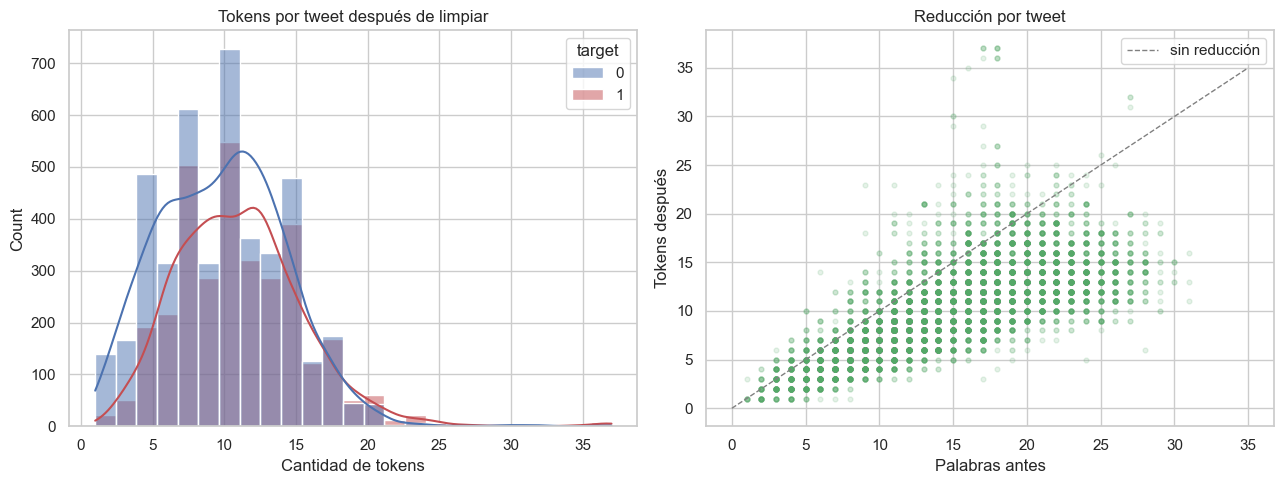

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x="n_tokens", hue="target", bins=25, kde=True,
             palette=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_title("Tokens por tweet después de limpiar")
axes[0].set_xlabel("Cantidad de tokens")

comparacion = pd.DataFrame({
    "palabras_antes": df["text"].str.split().str.len(),
    "tokens_después": df["n_tokens"],
})
axes[1].scatter(comparacion["palabras_antes"], comparacion["tokens_después"],
                alpha=0.15, s=12, color="#55A868")
axes[1].plot([0, 35], [0, 35], "--", color="gray", linewidth=1, label="sin reducción")
axes[1].set_xlabel("Palabras antes")
axes[1].set_ylabel("Tokens después")
axes[1].set_title("Reducción por tweet")
axes[1].legend()

plt.tight_layout()
plt.show()


In [5]:
df.groupby("target")["n_tokens"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4342.0,9.86,4.41,1.0,6.0,10.0,13.0,37.0
1,3271.0,11.07,4.46,1.0,8.0,11.0,14.0,37.0


**Observación:** tras la limpieza los tweets de desastre real siguen siendo
algo más largos, coherente con lo visto en el EDA del texto crudo. La nube de
puntos muestra que la reducción es proporcional y que ningún tweet quedó
vacío.


## 4. Palabras más frecuentes por clase

Se recalculan sobre el texto lematizado. Los tokens-flag (`flagnumero`,
`flaghashtag`, …) se excluyen de estos conteos porque no son palabras del
tweet: son marcas que agregó el pipeline y dominarían el ranking.


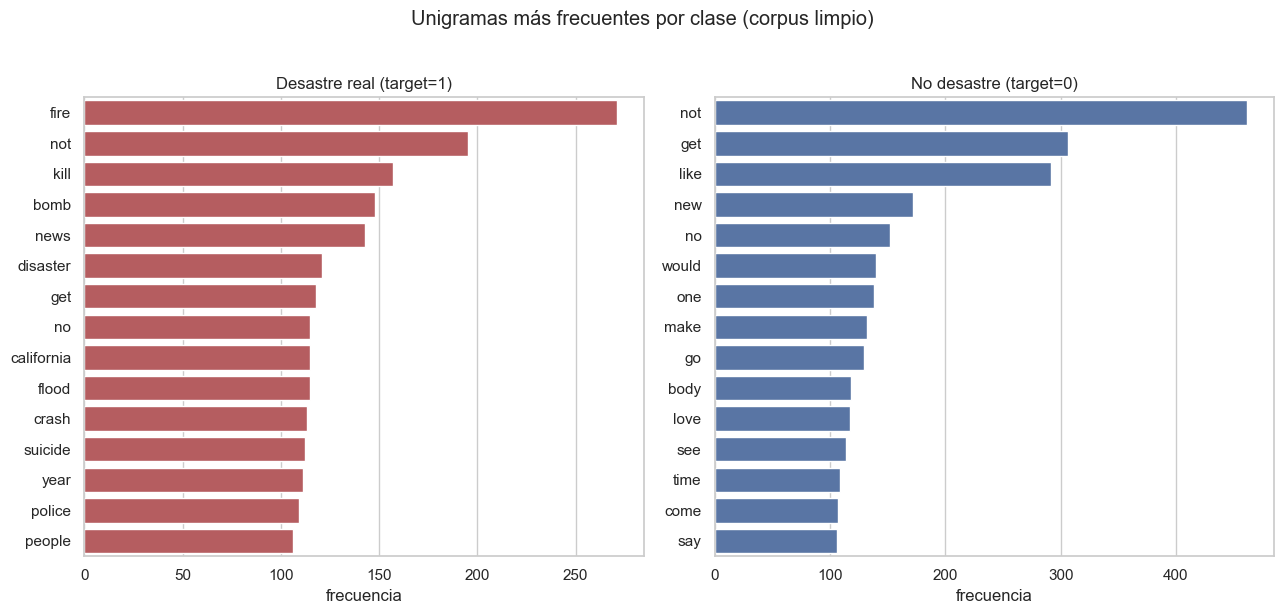

In [6]:
FLAGS = {"flagnumero", "flagemergencia", "flagnoemergencia",
         "flaghashtag", "flagmencion"}


def contar(serie, excluir_flags=True, n=None):
    c = Counter()
    for items in serie:
        c.update(i for i in items
                 if not (excluir_flags and any(f in i for f in FLAGS)))
    return c.most_common(n) if n else c


top_1 = contar(df.loc[df["target"] == 1, "tokens"], n=15)
top_0 = contar(df.loc[df["target"] == 0, "tokens"], n=15)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(x=[c for _, c in top_1], y=[w for w, _ in top_1],
            ax=axes[0], color="#C44E52")
axes[0].set_title("Desastre real (target=1)")
axes[0].set_xlabel("frecuencia")

sns.barplot(x=[c for _, c in top_0], y=[w for w, _ in top_0],
            ax=axes[1], color="#4C72B0")
axes[1].set_title("No desastre (target=0)")
axes[1].set_xlabel("frecuencia")

plt.suptitle("Unigramas más frecuentes por clase (corpus limpio)", y=1.02)
plt.tight_layout()
plt.show()


### Palabras que más discriminan

La frecuencia bruta no basta: `people` es común en ambas clases. Se calcula el
**log-odds** de cada palabra, que mide hacia qué clase se inclina, considerando
solo palabras con frecuencia suficiente para ser confiables.


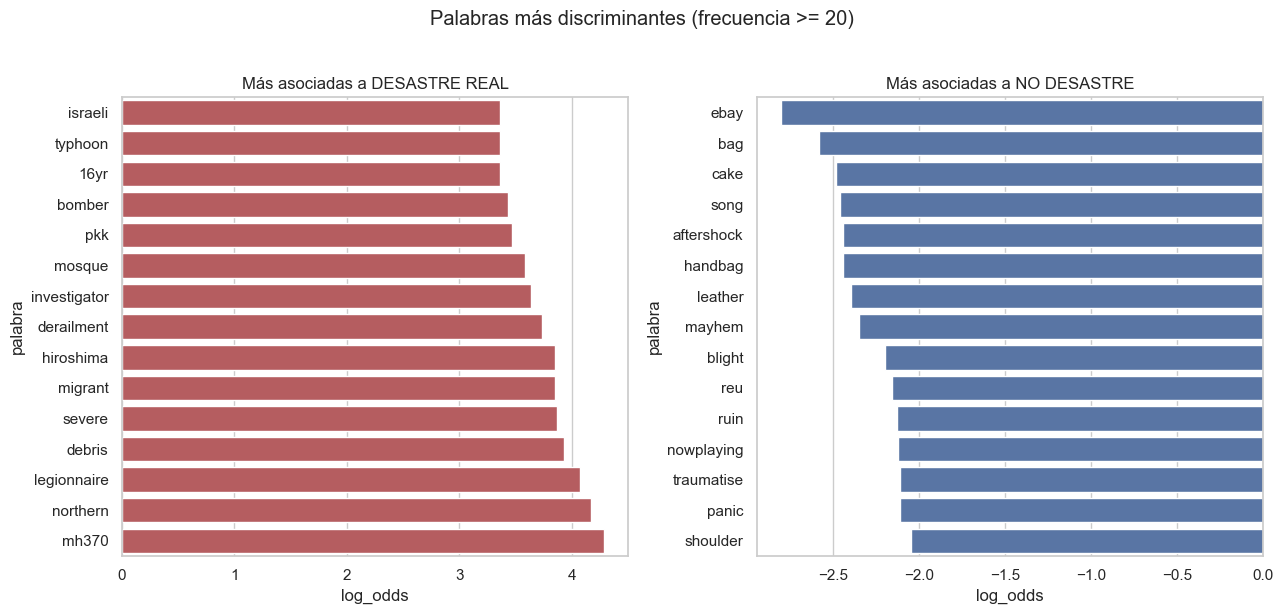

In [7]:
conteo_1 = contar(df.loc[df["target"] == 1, "tokens"])
conteo_0 = contar(df.loc[df["target"] == 0, "tokens"])

MIN_FREQ = 20
filas = []
for palabra in set(conteo_1) | set(conteo_0):
    c1, c0 = conteo_1.get(palabra, 0), conteo_0.get(palabra, 0)
    if c1 + c0 >= MIN_FREQ:
        # +1 de suavizado para evitar división por cero
        filas.append((palabra, c1, c0, np.log((c1 + 1) / (c0 + 1))))

log_odds = pd.DataFrame(filas, columns=["palabra", "n_desastre", "n_no_desastre",
                                        "log_odds"]).sort_values("log_odds")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
top_desastre = log_odds.tail(15)
top_no = log_odds.head(15)

sns.barplot(data=top_desastre, x="log_odds", y="palabra", ax=axes[0], color="#C44E52")
axes[0].set_title("Más asociadas a DESASTRE REAL")
sns.barplot(data=top_no, x="log_odds", y="palabra", ax=axes[1], color="#4C72B0")
axes[1].set_title("Más asociadas a NO DESASTRE")

plt.suptitle(f"Palabras más discriminantes (frecuencia >= {MIN_FREQ})", y=1.02)
plt.tight_layout()
plt.show()


**Observación:** las palabras más discriminantes hacia desastre real son
términos de eventos y cobertura noticiosa (`wildfire`, `earthquake`,
`derailment`, `evacuation`), mientras que hacia no-desastre aparecen verbos y
expresiones de conversación cotidiana. La separación es más nítida que en el
texto crudo, porque la lematización juntó las variantes de cada palabra.


## 5. Nubes de palabras (corpus limpio)

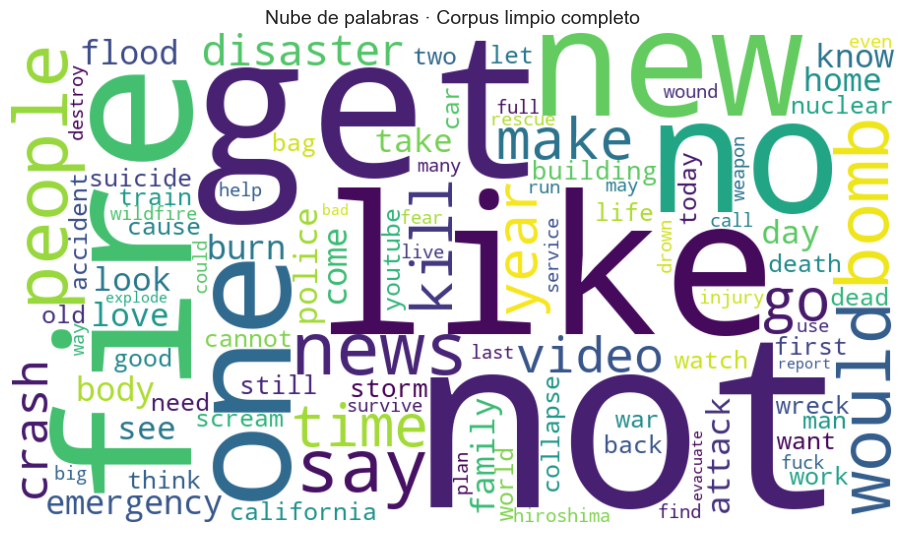

In [8]:
def nube(frecuencias, titulo, colormap="viridis"):
    wc = WordCloud(width=900, height=500, background_color="white",
                   colormap=colormap, max_words=100,
                   random_state=SEMILLA).generate_from_frequencies(frecuencias)
    plt.figure(figsize=(10, 5.5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()


nube(contar(df["tokens"]), "Nube de palabras · Corpus limpio completo", "viridis")


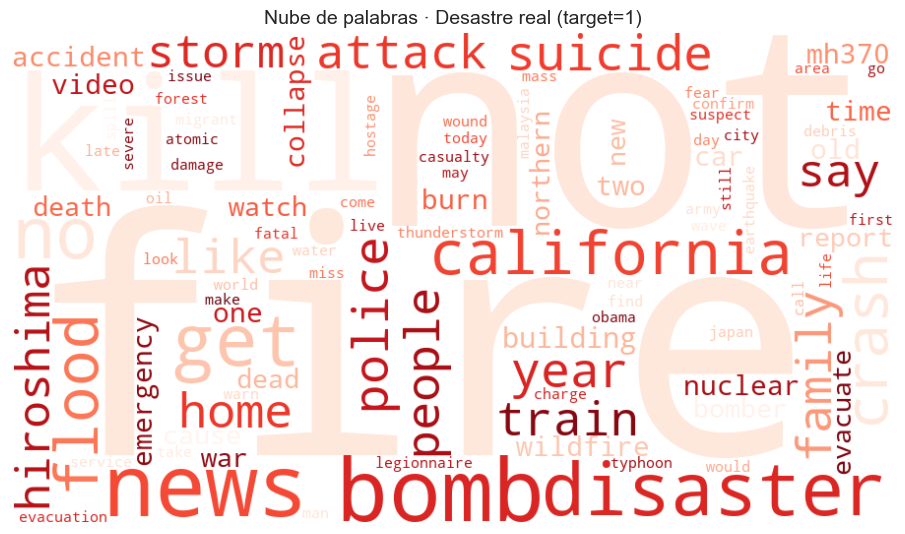

In [9]:
nube(contar(df.loc[df["target"] == 1, "tokens"]),
     "Nube de palabras · Desastre real (target=1)", "Reds")


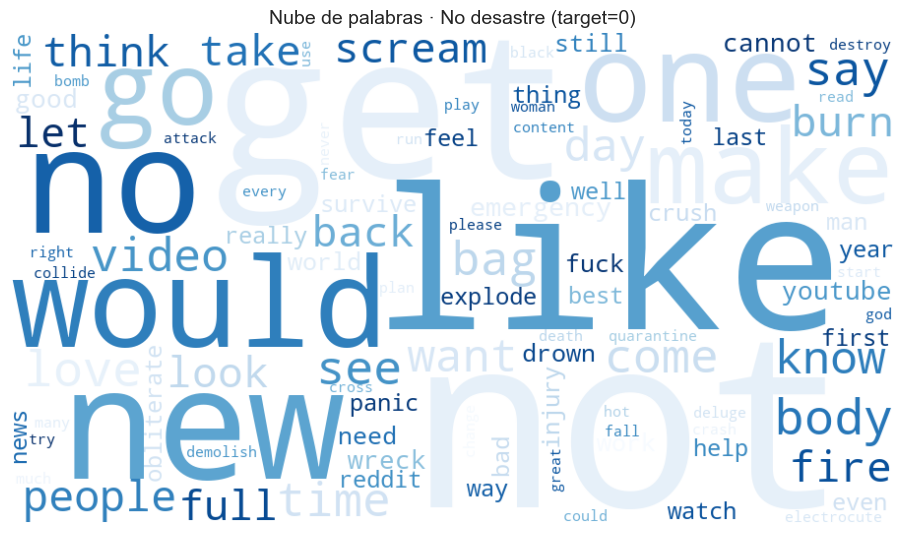

In [10]:
nube(contar(df.loc[df["target"] == 0, "tokens"]),
     "Nube de palabras · No desastre (target=0)", "Blues")


**Observación:** comparadas con las nubes del texto crudo, estas son mucho
más legibles: desaparecieron `http`, `amp` y las variantes plurales, y quedan
los términos con contenido. La nube de desastre real se concentra en eventos
concretos; la de no-desastre, en lenguaje conversacional.


## 6. Bigramas más frecuentes

Aquí sí se muestran los bigramas que incluyen flags, porque son parte del
diseño del pipeline, pero se marcan aparte para no confundirlos con lenguaje
real.


In [11]:
bigramas_todos = Counter()
for b in df["bigramas"]:
    bigramas_todos.update(b)

top_con_flags = pd.DataFrame(bigramas_todos.most_common(12),
                             columns=["bigrama", "frecuencia"])
top_con_flags["es_flag"] = top_con_flags["bigrama"].apply(
    lambda b: any(f in b for f in FLAGS)
)
top_con_flags


,bigrama,frecuencia,es_flag
0,flagnumero_flagnoemergencia,2424,True
1,flagnoemergencia_flagnumero,513,True
2,flagnoemergencia_flaghashtag,103,True
3,flagnoemergencia_year,92,True
4,flagmencion_youtube,83,True
5,flaghashtag_news,74,True
6,body_bag,74,False
7,suicide_bomber,60,False
8,look_like,55,False
9,kill_flagnumero,48,True


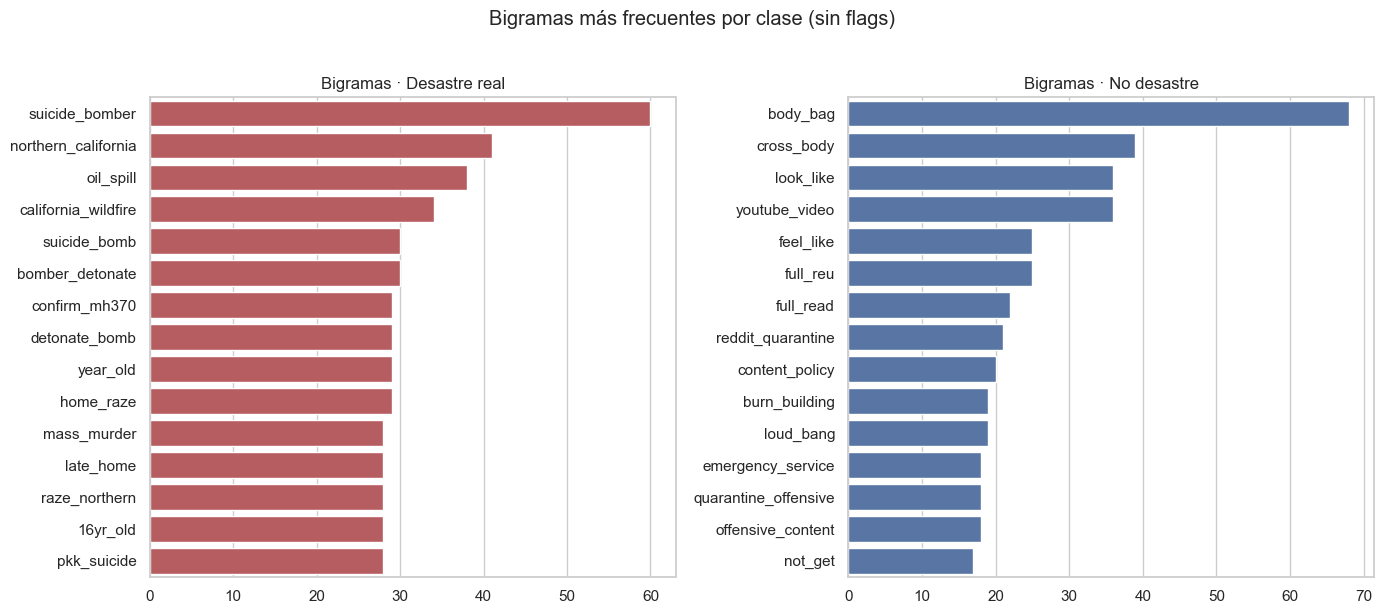

In [12]:
bigramas_reales = contar(df["bigramas"])  # excluye flags

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
b1 = contar(df.loc[df["target"] == 1, "bigramas"], n=15)
b0 = contar(df.loc[df["target"] == 0, "bigramas"], n=15)

sns.barplot(x=[c for _, c in b1], y=[w for w, _ in b1], ax=axes[0], color="#C44E52")
axes[0].set_title("Bigramas · Desastre real")
sns.barplot(x=[c for _, c in b0], y=[w for w, _ in b0], ax=axes[1], color="#4C72B0")
axes[1].set_title("Bigramas · No desastre")

plt.suptitle("Bigramas más frecuentes por clase (sin flags)", y=1.02)
plt.tight_layout()
plt.show()


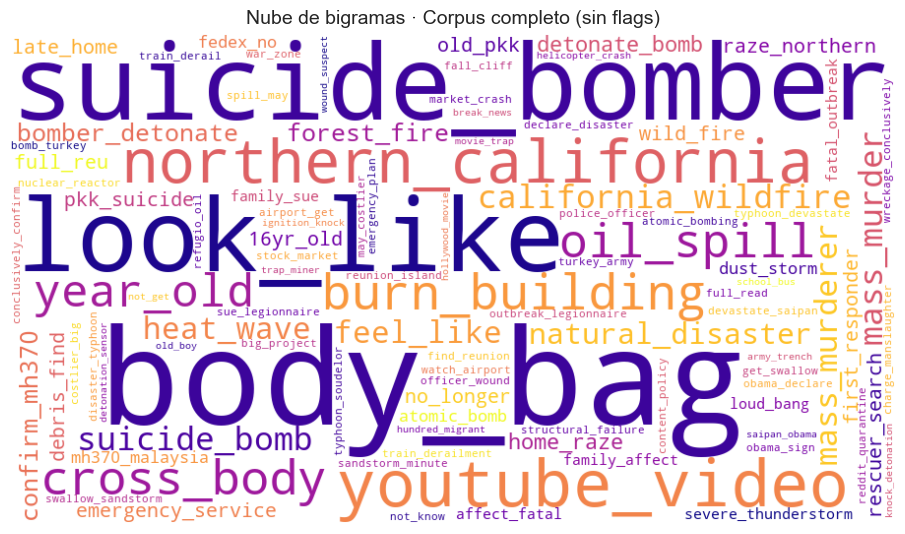

In [13]:
nube(bigramas_reales, "Nube de bigramas · Corpus completo (sin flags)", "plasma")


**Observación:** los bigramas frecuentes sí son expresiones con sentido
propio: `suicide_bomber`, `oil_spill`, `northern_california`,
`severe_thunderstorm`, `body_bag`. Es exactamente el tipo de expresión compuesta
que motivó la pregunta. La sección siguiente mide si eso se traduce en un mejor
clasificador.


## 7. ¿Aportan los bigramas?

Tres evidencias, de la más barata a la más costosa.

### 7.1 Dispersión: la mayoría de bigramas no se repite


In [14]:
frecs_bi = np.array(list(bigramas_todos.values()))
frecs_uni = np.array(list(vocab_uni.values()))

cobertura = pd.DataFrame({
    "aparece al menos": [1, 2, 5, 10],
    "unigramas": [(frecs_uni >= k).sum() for k in [1, 2, 5, 10]],
    "bigramas": [(frecs_bi >= k).sum() for k in [1, 2, 5, 10]],
})
cobertura


,aparece al menos,unigramas,bigramas
0,1,14579,48981
1,2,5448,6730
2,5,2364,1263
3,10,1297,417


De casi 49 000 bigramas distintos, solo ~1 300 aparecen 5 veces o más.
El resto es esencialmente ruido para un modelo estadístico.

### 7.2 Palabras compuestas: ¿el bigrama dice algo que sus partes no dicen?

Este es el punto central de la pregunta. Para cada expresión compuesta se
compara la probabilidad de ser desastre real dado el **bigrama** contra la que
dan sus **palabras sueltas**. Si el bigrama aporta, su probabilidad debe
alejarse de la de sus componentes.


In [15]:
conjuntos_uni = df["tokens"].apply(set)
conjuntos_bi = df["bigramas"].apply(set)


def tasa(mascara):
    return int(mascara.sum()), float(df.loc[mascara, "target"].mean())


compuestas = ["body_bag", "cross_body", "suicide_bomber", "oil_spill",
              "northern_california", "burn_building", "mass_murder",
              "severe_thunderstorm", "year_old", "look_like"]

filas = []
for bigrama in compuestas:
    p1, p2 = bigrama.split("_")
    n_b, t_b = tasa(conjuntos_bi.apply(lambda s: bigrama in s))
    n_1, t_1 = tasa(conjuntos_uni.apply(lambda s: p1 in s))
    n_2, t_2 = tasa(conjuntos_uni.apply(lambda s: p2 in s))
    filas.append({
        "bigrama": bigrama, "n": n_b, "P(desastre|bigrama)": round(t_b, 2),
        f"palabra 1": p1, "P(des|p1)": round(t_1, 2),
        f"palabra 2": p2, "P(des|p2)": round(t_2, 2),
        "desvío vs partes": round(abs(t_b - (t_1 + t_2) / 2), 2),
    })

tabla_compuestas = pd.DataFrame(filas).sort_values("desvío vs partes",
                                                   ascending=False)
tabla_compuestas


,bigrama,n,P(desastre|bigrama),palabra 1,P(des|p1),palabra 2,P(des|p2),desvío vs partes
1,cross_body,40,0.03,cross,0.23,body,0.24,0.21
8,year_old,25,0.76,year,0.61,old,0.69,0.11
6,mass_murder,33,0.85,mass,0.67,murder,0.82,0.10
3,oil_spill,37,0.97,oil,0.79,spill,0.98,0.09
7,severe_thunderstorm,26,1.00,severe,1.00,thunderstorm,0.84,0.08
0,body_bag,73,0.08,body,0.24,bag,0.07,0.07
2,suicide_bomber,58,1.00,suicide,0.93,bomber,0.98,0.04
4,northern_california,41,1.00,northern,1.00,california,0.95,0.03
9,look_like,55,0.35,look,0.38,like,0.26,0.03
5,burn_building,41,0.54,burn,0.44,building,0.67,0.02


**Lectura de la tabla — esto responde directamente la duda de `body bag`:**

- **`body_bag` es el caso que sí justifica bigramas.** Solo 8% de los tweets que
  lo contienen son desastres reales, contra 24% de los que contienen `body`
  suelto. El bigrama **corrige** la interpretación: mirando `body` aislado el
  modelo tendería a asociarlo a desastre, cuando en este corpus casi siempre es
  un *cross body bag* (una cartera). `cross_body` confirma el patrón con 3%.

- **La mayoría de las compuestas, en cambio, es redundante.** En
  `suicide_bomber` (100%), `oil_spill` (97%) o `northern_california` (100%) las
  palabras sueltas **ya son casi igual de discriminantes** (`suicide` 93%,
  `spill` 98%, `northern` 100%). El bigrama confirma lo que el unigrama ya
  decía, así que no agrega información nueva.

Entonces los bigramas sí desambiguan, pero **en pocos casos**: `body_bag` y
`cross_body` juntos aparecen en ~113 tweets, un **1.5%** del corpus. Esa es la
razón por la que, como se ve a continuación, el efecto global es pequeño.

### 7.3 El experimento: ¿mejora el clasificador?

Se compara TF-IDF con unigramas contra unigramas+bigramas, con validación
cruzada estratificada de 5 folds y F1 como métrica (elegida por el desbalance
leve de clases). Se prueban dos modelos y dos valores de `min_df` (frecuencia
mínima para que un término entre al vocabulario).


In [16]:
%%time
X, y = df["texto_limpio"].fillna(""), df["target"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

configuraciones = []
for nombre_modelo, modelo in [
    ("LogReg", LogisticRegression(max_iter=1000)),
    ("NaiveBayes", MultinomialNB()),
]:
    for rango, etiqueta in [((1, 1), "solo unigramas"),
                            ((1, 2), "uni + bigramas"),
                            ((2, 2), "solo bigramas")]:
        for min_df in [1, 2]:
            vec = TfidfVectorizer(ngram_range=rango, min_df=min_df)
            scores = cross_val_score(make_pipeline(vec, modelo), X, y,
                                     cv=cv, scoring="f1", n_jobs=-1)
            n_feats = len(TfidfVectorizer(ngram_range=rango,
                                          min_df=min_df).fit(X).vocabulary_)
            configuraciones.append({
                "modelo": nombre_modelo, "n-gramas": etiqueta, "min_df": min_df,
                "F1 medio": round(scores.mean(), 4),
                "desv. est.": round(scores.std(), 4),
                "features": n_feats,
            })

resultados = pd.DataFrame(configuraciones)
resultados.sort_values("F1 medio", ascending=False)


CPU times: total: 2.25 s
Wall time: 12.3 s


,modelo,n-gramas,min_df,F1 medio,desv. est.,features
3,LogReg,uni + bigramas,2,0.7504,0.0105,11918
1,LogReg,solo unigramas,2,0.7458,0.0162,5322
0,LogReg,solo unigramas,1,0.7442,0.0146,14578
7,NaiveBayes,solo unigramas,2,0.7442,0.0122,5322
6,NaiveBayes,solo unigramas,1,0.7434,0.0124,14578
2,LogReg,uni + bigramas,1,0.7404,0.0112,63558
8,NaiveBayes,uni + bigramas,1,0.7370,0.0149,63558
9,NaiveBayes,uni + bigramas,2,0.7340,0.0188,11918
10,NaiveBayes,solo bigramas,1,0.6859,0.0112,48980
11,NaiveBayes,solo bigramas,2,0.6504,0.0049,6596


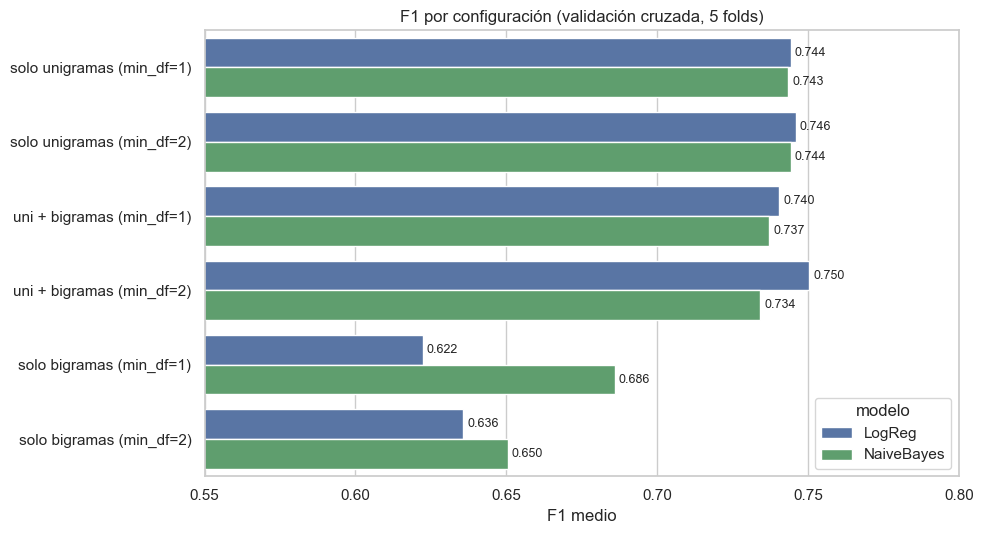

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))
graf = resultados.copy()
graf["config"] = graf["n-gramas"] + " (min_df=" + graf["min_df"].astype(str) + ")"

sns.barplot(data=graf, x="F1 medio", y="config", hue="modelo",
            palette=["#4C72B0", "#55A868"], ax=ax)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlim(0.55, 0.80)
ax.set_title("F1 por configuración (validación cruzada, 5 folds)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### ¿La diferencia es real o es ruido?

La mejor configuración con bigramas supera a la mejor con unigramas por un
margen pequeño. Para saber si esa diferencia es significativa se comparan los
**mismos folds** con una prueba t pareada.


In [18]:
def f1_por_fold(rango, min_df=2):
    pipe = make_pipeline(TfidfVectorizer(ngram_range=rango, min_df=min_df),
                         LogisticRegression(max_iter=1000))
    return cross_val_score(pipe, X, y, cv=cv, scoring="f1")


f1_uni = f1_por_fold((1, 1))
f1_unibi = f1_por_fold((1, 2))

t_stat, p_valor = stats.ttest_rel(f1_unibi, f1_uni)

comparacion_folds = pd.DataFrame({
    "fold": range(1, 6),
    "solo unigramas": f1_uni.round(4),
    "uni + bigramas": f1_unibi.round(4),
    "diferencia": (f1_unibi - f1_uni).round(4),
})
print(comparacion_folds.to_string(index=False))
print(f"\nDiferencia media: {(f1_unibi - f1_uni).mean():+.4f}")
print(f"t = {t_stat:.3f}   p = {p_valor:.4f}")
print("\nSignificativa al 5%:", "SÍ" if p_valor < 0.05 else "NO")


 fold  solo unigramas  uni + bigramas  diferencia
    1          0.7496          0.7579      0.0083
    2          0.7556          0.7534     -0.0023
    3          0.7137          0.7295      0.0158
    4          0.7557          0.7549     -0.0008
    5          0.7544          0.7563      0.0019

Diferencia media: +0.0046
t = 1.368   p = 0.2432

Significativa al 5%: NO


## 8. Conclusión y recomendación

**Los bigramas no producen una mejora estadísticamente significativa.** Los
resultados medidos:

| Configuración | F1 | Features |
|---|---|---|
| Solo unigramas (`min_df=2`) | 0.746 | 5 322 |
| **Uni + bigramas (`min_df=2`)** | **0.750** | 11 918 |
| Uni + bigramas (`min_df=1`) | 0.740 | 63 558 |
| Solo bigramas (`min_df=2`) | 0.636 | 6 596 |

La ganancia de agregar bigramas es de **+0.005 F1**, con **p ≈ 0.24** en la
prueba pareada: por debajo del umbral de significancia, y menor que la
variación entre folds (±0.011). En dos de los cinco folds los bigramas
resultaron incluso *peores*.

**Por qué pasa esto, a pesar de que `body bag` sí existe:**

1. Los bigramas que desambiguan de verdad (`body_bag`, `cross_body`) aparecen en
   ~1.5% de los tweets. Aun resolviéndolos todos, el efecto sobre la métrica
   global es mínimo.
2. En el resto de las compuestas (`suicide_bomber`, `oil_spill`,
   `northern_california`) los unigramas **ya capturan casi toda la señal**, así
   que el bigrama es redundante.
3. El 86% de los bigramas aparece una sola vez: son features que el modelo no
   puede aprovechar y que solo diluyen el peso de las que sí importan.

**Recomendación: usar `ngram_range=(1, 2)` con `min_df=2`.** No porque la
mejora sea significativa —no lo es— sino porque:

- da el mejor F1 puntual y **nunca resulta peor** que solo unigramas;
- duplica las features (5 mil → 12 mil), un costo bajo para este tamaño de
  dataset;
- conserva la interpretabilidad de casos como `body_bag`, útil al analizar los
  errores del modelo.

Lo que **sí importa mucho más que el rango de n-gramas es `min_df`**: pasar de
`min_df=1` a `min_df=2` con bigramas mejora el F1 de 0.740 a 0.750 y recorta el
vocabulario de 63 558 a 11 918 términos. Filtrar los términos que aparecen una
sola vez es la decisión con impacto real; el rango de n-gramas es secundario.

> Nota de alcance: estos F1 (~0.75) provienen de modelos base sin optimizar,
> usados aquí solo como **instrumento de comparación** entre configuraciones de
> n-gramas. No son el resultado final de clasificación: ese se construye en el
> siguiente paso, ajustando hiperparámetros y probando otros modelos.
